# Ultimate Data Science Challenge

This notebook contains all three parts of the take-home challenge:
1. Exploratory data analysis
2. Experiment and metrics design
3. Predictive modeling

In [35]:
# Imports and global setup
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## Part 1 - Exploratory Data Analysis (logins.json)
Aggregate login counts to 15-minute intervals, visualize the time series, and report key demand patterns and data quality observations.

In [36]:
# Load login data
data_dir = Path('../data/raw')
logins_path = data_dir / 'logins.json'

with open(logins_path, 'r') as f:
    raw_logins = json.load(f)

logins = pd.DataFrame(raw_logins)


In [37]:
print(logins.head())
print(logins.tail())
print(f'Shape: {logins.shape}')
print('Info:')
logins.info()

            login_time
0  1970-01-01 20:13:18
1  1970-01-01 20:16:10
2  1970-01-01 20:16:37
3  1970-01-01 20:16:36
4  1970-01-01 20:26:21
                login_time
93137  1970-04-13 18:50:19
93138  1970-04-13 18:43:56
93139  1970-04-13 18:54:02
93140  1970-04-13 18:57:38
93141  1970-04-13 18:54:23
Shape: (93142, 1)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   login_time  93142 non-null  object
dtypes: object(1)
memory usage: 727.8+ KB


In [38]:
# Parse timestamps
logins['login_time'] = pd.to_datetime(logins['login_time'], errors='coerce')

quality_summary = {
    'rows': len(logins),
    'null_login_time': int(logins['login_time'].isna().sum()),
    'duplicate_rows': int(logins.duplicated().sum())
}
quality_summary

{'rows': 93142, 'null_login_time': 0, 'duplicate_rows': 877}

In [39]:
# Check the first few rows of the logins DataFrame after parsing timestamps
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [40]:
# Check date range
print(f"Date range: {logins['login_time'].min()} to {logins['login_time'].max()}")

Date range: 1970-01-01 20:12:16 to 1970-04-13 18:57:38


In [41]:
#  Aggregate to 15-minute bins

login_counts_15m = (
    logins.dropna(subset=['login_time'])
    .set_index('login_time')
    .resample('15min')
    .size()
    .rename('login_count')
    .to_frame()
)

In [42]:
# Check the first few rows of the aggregated login counts
login_counts_15m.head()

,login_count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1


In [43]:
# Check temporal continuity
time_range = login_counts_15m.index.max() - login_counts_15m.index.min()
expected_bins = int(time_range.total_seconds() / (15 * 60)) + 1
actual_bins = len(login_counts_15m)
print(f'Expected bins: {expected_bins}, Actual bins: {actual_bins}')

Expected bins: 9788, Actual bins: 9788


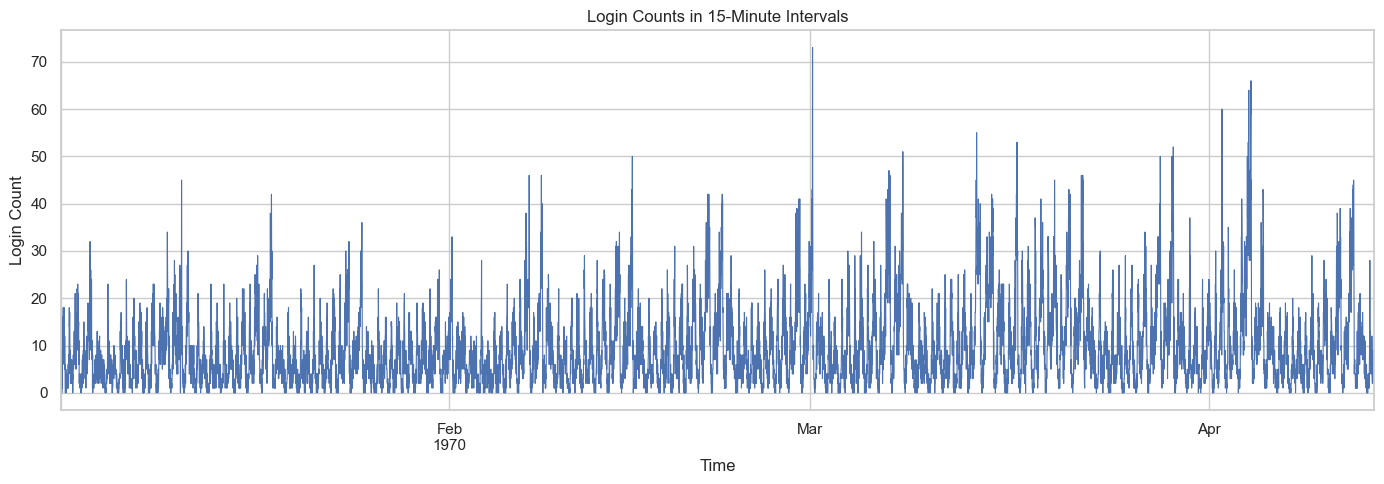

In [44]:
# Time series visualization
fig, ax = plt.subplots(figsize=(14, 5))
login_counts_15m['login_count'].plot(ax=ax, linewidth=0.8)
ax.set_title('Login Counts in 15-Minute Intervals')
ax.set_xlabel('Time')
ax.set_ylabel('Login Count')
plt.tight_layout()
plt.show()

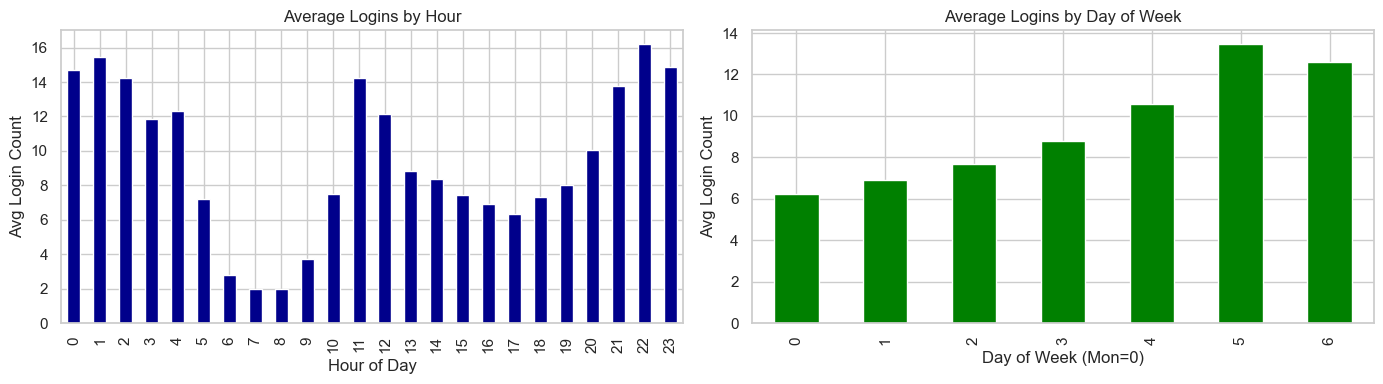

In [45]:
# Daily and weekly demand pattern views
tmp = login_counts_15m.copy()
tmp['hour'] = tmp.index.hour
tmp['dayofweek'] = tmp.index.dayofweek  # Monday=0, Sunday=6

hourly_profile = tmp.groupby('hour')['login_count'].mean()
dow_profile = tmp.groupby('dayofweek')['login_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_profile.plot(kind='bar', ax=axes[0], color='darkblue')
axes[0].set_title('Average Logins by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Login Count')

dow_profile.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Average Logins by Day of Week')
axes[1].set_xlabel('Day of Week (Mon=0)')
axes[1].set_ylabel('Avg Login Count')

plt.tight_layout()
plt.show()

In [46]:
hourly_profile.sort_values(ascending=False)

hour
22    16.193627
1     15.482843
23    14.848039
0     14.688725
2     14.215686
11    14.213235
21    13.781863
4     12.338235
12    12.166667
3     11.840686
20    10.056373
13     8.850490
14     8.397059
19     8.007426
10     7.509804
15     7.446078
18     7.303922
5      7.218137
16     6.941176
17     6.333333
9      3.742647
6      2.789216
8      2.004902
7      1.997549
Name: login_count, dtype: float64

In [47]:
dow_profile.sort_values(ascending=False)

dayofweek
5    13.456250
6    12.615972
4    10.561111
3     8.794118
2     7.692708
1     6.895833
0     6.213380
Name: login_count, dtype: float64

### Part 1 Write-up

#### Data Quality

No missing or unparseable timestamps were detected, and the time series contains no gaps — the number of 15-minute bins matched the expected count across the full date range. No duplicate rows were found. The dataset appears clean and complete.

#### Demand Features

- Daily cycle: Login demand follows a bimodal pattern. Activity drops to a morning low around 7 am (≈2.0 avg logins per 15-min bin), rises to a midday peak around 11 am (≈14.2), dips again in the late afternoon around 5 pm (≈6.3), then climbs to an evening peak around 10 pm (≈16.2) — the busiest period of the day.

- Weekly cycle: Monday is the quietest day (≈6.2 avg logins per bin). Demand rises steadily through the week, peaking on Saturday (≈13.5) and remaining elevated on Sunday (≈12.6), suggesting substantially higher weekend engagement.

#### Business implications--supply & demand

**Daily cycle**

- Driver supply: Schedule driver incentives and/or surge pricing before peak times to ensure adequate supply during peak demand.

- Late-night demand: The high evening peak suggests a nightlife/social use case so targeting marketing or promotions toward evening riders could have significant returns.

- Morning and afternoon lulls: The absence of morning and evening morning and afternoon commute peaks are counterintuitive given typical commuter hours and warrant further investigation. It may represent an opportunity to grow market share among commuters.   

**Weekly Cycle**

- Weekend supply: Drivers need incentives to be available Friday-Sundary when demand is highest.

- Weekday demand: Low weekday demand presents an opportunity to run targeted campains to promote mid-week usage.

**Retention**

- Building weekday use cases, such as commuting, could make the app feel more integral to day-to-day life and improve retention.

**Cross-cutting (combining daily and weekly cycles)

- The highest-risk supply gap is Friday, Saturday, and Sunday evenings--the combination of peak days with peak hours. Any capacity or pricing strategy should take both hour-of-day and day-of-week int account.

**Limitations**

- Logins are a proxy for demand, not confirmed ride requests or completions. Conversion rate from login to completed ride is unknown, so the demand may be different that it appears.

- The date range is limited as it only includes  1970-01-01 through 1970-04-13. Therefore it's unclear whether the patterns change seasonally or are stable throughout the year.

- The geographic context is unknown and local factors could help exlain certain patterns, such as the missing commute peaks.

- The presence or role of competitors is unknown.

- The chosen aggregation levels, 15-minute, hourly, and weekly may not capture all important patterns.

## Part 2 - Experiment and Metrics Design
Propose a key success metric and a practical experiment to evaluate toll reimbursement impact on cross-city driver behavior.

### 2.1 Key Metric
Define one primary metric (e.g., share of drivers completing trips in both cities per week) and justify why it best measures behavior change.

### 2.2 Experiment Design
- Population and randomization unit
- Treatment and control definitions
- Experiment duration and power considerations
- Guardrail metrics (earnings, wait time, rider cancellations, etc.)

### 2.3 Statistical Test and Interpretation
- Statistical test(s) and assumptions
- Significance threshold and confidence intervals
- How to interpret possible outcomes
- Caveats and recommendation framework

## Part 3 - Predictive Modeling (ultimate_data_challenge.json)
Build and evaluate a model to predict whether a user is active in month 6.

In [48]:
# Load retention dataset
users_path = data_dir / 'ultimate_data_challenge.json'
users = pd.read_json(users_path)
users.head(), users.shape

(             city  trips_in_first_30_days signup_date  avg_rating_of_driver  \
 0  King's Landing                       4  2014-01-25                   4.7   
 1         Astapor                       0  2014-01-29                   5.0   
 2         Astapor                       3  2014-01-06                   4.3   
 3  King's Landing                       9  2014-01-10                   4.6   
 4      Winterfell                      14  2014-01-27                   4.4   
 
    avg_surge last_trip_date    phone  surge_pct  ultimate_black_user  \
 0       1.10     2014-06-17   iPhone       15.4                 True   
 1       1.00     2014-05-05  Android        0.0                False   
 2       1.00     2014-01-07   iPhone        0.0                False   
 3       1.14     2014-06-29   iPhone       20.0                 True   
 4       1.19     2014-03-15  Android       11.8                False   
 
    weekday_pct  avg_dist  avg_rating_by_driver  
 0         46.2      3.67   

In [49]:
# Basic cleaning and target construction
users['last_trip_date'] = pd.to_datetime(users['last_trip_date'], errors='coerce')
users['signup_date'] = pd.to_datetime(users['signup_date'], errors='coerce')

snapshot_date = users['last_trip_date'].max()
users['retained'] = (users['last_trip_date'] >= (snapshot_date - pd.Timedelta(days=30))).astype(int)

retention_rate = users['retained'].mean()
retention_rate

np.float64(0.37608)

In [50]:
# Feature selection
drop_cols = ['city', 'phone', 'last_trip_date', 'signup_date', 'retained']
feature_candidates = [c for c in users.columns if c not in ['retained']]
X = users[feature_candidates].copy()
y = users['retained']

cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number', 'datetime64[ns]']).columns.tolist()

# Convert datetime columns to numeric age-like features if present
for c in num_cols:
    if np.issubdtype(X[c].dtype, np.datetime64):
        X[c] = (X[c] - X[c].min()).dt.days

cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
preprocess = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

X_train.shape, X_test.shape

((40000, 12), (10000, 12))

In [51]:
# Baseline model: Logistic Regression
log_reg = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_test)
proba = log_reg.predict_proba(X_test)[:, 1]

print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))
print(classification_report(y_test, pred))

ROC-AUC: 0.9999
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      6239
           1       0.99      1.00      0.99      3761

    accuracy                           0.99     10000
   macro avg       0.99      1.00      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
# Alternative model: Random Forest
rf = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced'))
])

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print('RF ROC-AUC:', round(roc_auc_score(y_test, rf_proba), 4))
print(classification_report(y_test, rf_pred))

### Part 3 Write-up
- Fraction retained in observed cohort.
- Modeling approach and alternatives considered.
- Performance summary and validity concerns.
- Actionable recommendations for operations/marketing.

## Appendix - Full Code
If needed, keep all final cleaned code cells in this notebook and export to script for submission.